<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Image_Classification_with_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasunroy/natural-images")

print("Path to dataset files:", path)

100%|██████████| 342M/342M [00:05<00:00, 69.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prasunroy/natural-images/versions/1


In [2]:
import os

print(os.listdir(path))

['natural_images', 'data']


In [3]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

1/
    natural_images/
        person/
            person_0806.jpg
            person_0946.jpg
            person_0639.jpg
            person_0109.jpg
            person_0093.jpg
        dog/
            dog_0455.jpg
            dog_0449.jpg
            dog_0207.jpg
            dog_0131.jpg
            dog_0070.jpg
        motorbike/
            motorbike_0669.jpg
            motorbike_0434.jpg
            motorbike_0505.jpg
            motorbike_0518.jpg
            motorbike_0479.jpg
        fruit/
            fruit_0663.jpg
            fruit_0554.jpg
            fruit_0121.jpg
            fruit_0465.jpg
            fruit_0230.jpg
        car/
            car_0890.jpg
            car_0714.jpg
            car_0518.jpg
            car_0264.jpg
            car_0180.jpg
        flower/
            flower_0328.jpg
            flower_0765.jpg
            flower_0545.jpg
            flower_0097.jpg
            flower_0537.jpg
        cat/
            cat_0428.jpg
            cat_0729.jpg
  

#preprocess the dataset

In [4]:
import os

dataset_dir = os.path.join(path, "natural_images")

classes = sorted(os.listdir(dataset_dir))

print("Classes:", classes)
print("Number of classes:", len(classes))

for class_name in classes:
    class_path = os.path.join(dataset_dir, class_name)
    print(f"{class_name}: {len(os.listdir(class_path))} images")

Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Number of classes: 8
airplane: 727 images
car: 968 images
cat: 885 images
dog: 702 images
flower: 843 images
fruit: 1000 images
motorbike: 788 images
person: 986 images


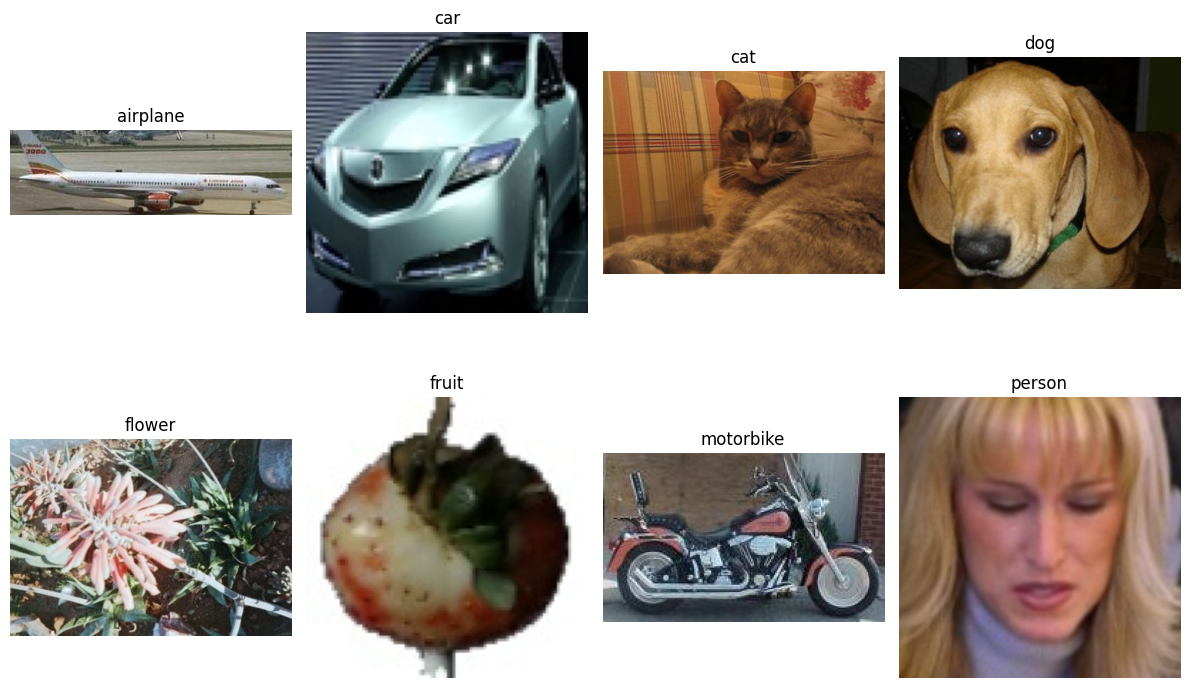

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6899 files belonging to 8 classes.
Using 5520 files for training.
Found 6899 files belonging to 8 classes.
Using 1379 files for validation.


In [7]:
class_names = train_ds.class_names

print("Class names:", class_names)

Class names: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

# designing the CNN architecture

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,568 (12.61 MB)

 Trainable params: 3,306,120 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.5656 - loss: 1.7936 - val_accuracy: 0.2966 - val_loss: 5.8563
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.6803 - loss: 1.0287 - val_accuracy: 0.4097 - val_loss: 3.4996
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.7250 - loss: 0.8761 - val_accuracy: 0.7592 - val_loss: 0.6921
Epoch 4/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7429 - loss: 0.7917 - val_accuracy: 0.5664 - val_loss: 5.4533
Epoch 5/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.7694 - loss: 0.7023 - val_accuracy: 0.8680 - val_loss: 0.3434
Epoch 6/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.7980 - loss: 0.6013 - val_accuracy: 0.8042 - val_loss: 0.9572
Epoch 7/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7969 - loss: 0.6022 - val_accuracy: 0.6766 - val_loss: 1.4569
Epoch 8/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.8067 - loss: 0.5905 - val_accu

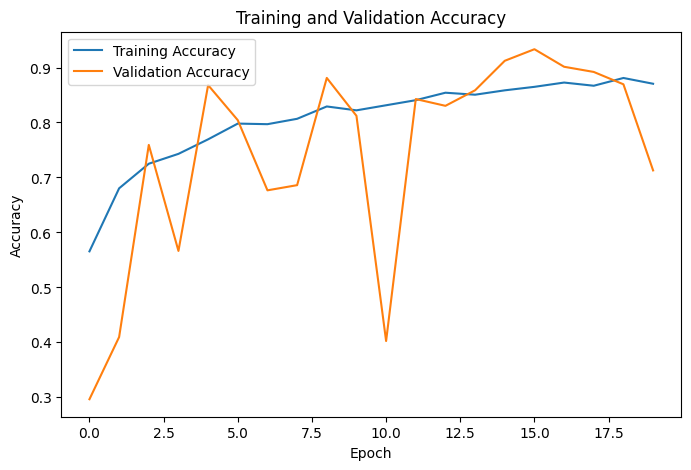

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

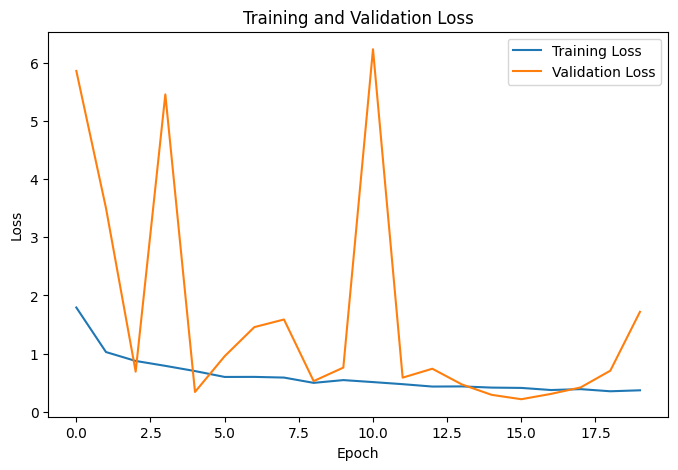

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       1.00      0.40      0.57       125
         car       1.00      0.72      0.84       184
         cat       0.56      0.72      0.63       173
         dog       0.44      0.65      0.53       159
      flower       0.51      0.98      0.67       169
       fruit       0.99      0.92      0.96       205
   motorbike       0.95      0.85      0.89       165
      person       1.00      0.39      0.56       199

    accuracy                           0.71      1379
   macro avg       0.81      0.70      0.71      1379
weighted avg       0.81      0.71      0.72      1379



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import os

image_paths = []
labels = []

for class_index, class_name in enumerate(classes):
    class_path = os.path.join(dataset_dir, class_name)

    for filename in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, filename))
        labels.append(class_index)

# 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Split temporary data equally: 15% validation, 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    return image, label


def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

In [19]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [22]:
import tensorflow as tf

def build_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),

        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(8, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
optimized_model = build_cnn()

history_opt = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.5436 - loss: 1.9661 - val_accuracy: 0.2937 - val_loss: 4.0324 - learning_rate: 0.0010
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.6138 - loss: 1.1941 - val_accuracy: 0.4406 - val_loss: 3.4926 - learning_rate: 0.0010
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.6511 - loss: 1.0587 - val_accuracy: 0.6628 - val_loss: 1.2277 - learning_rate: 0.0010
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.6983 - loss: 0.8859 - val_accuracy: 0.8097 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7368 - loss: 0.8073 - val_accuracy: 0.7111 - val_loss: 1.7986 - learning_rate: 0.0010
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7448 - loss: 0.7611
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
151/151 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.7457 - loss: 0.759

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [26]:
history_opt = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.9010 - loss: 0.2555 - val_accuracy: 0.9237 - val_loss: 0.2985 - learning_rate: 7.8125e-06
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9003 - loss: 0.2473
Epoch 2: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
151/151 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8981 - loss: 0.2675 - val_accuracy: 0.9275 - val_loss: 0.2890 - learning_rate: 7.8125e-06
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.8921 - loss: 0.2787 - val_accuracy: 0.9285 - val_loss: 0.2891 - learning_rate: 3.9063e-06
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9086 - loss: 0.2332
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
151/151 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.9006 - loss: 0.2491 - val_accuracy: 0.9275 - val_loss: 0.2854 - learning_rate: 3.9063e-06
